## Shared Setup

In [ ]:
!pip install -q datasets scikit-learn pandas matplotlib seaborn

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

print("Train:", train_df.shape, "| Validation:", val_df.shape, "| Test:", test_df.shape)


README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  699kB            

train.parquet: downloading bytes:           |  0.00B            

validation.parquet: reconstructing file:   0%|          |  0.00B / 90.0kB            

validation.parquet: downloading bytes:           |  0.00B            

...

test.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Train: (8530, 3) | Validation: (1066, 3) | Test: (1066, 3)


## 2. Implementation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000)),
])
print(logreg_pipeline)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=5, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf', LogisticRegression(max_iter=1000))])


## 3. Hyperparameter Tuning Across Varieties



In [ ]:
param_grid = {
    "tfidf__max_features":[1500, 2500, 4000],
    "clf__C": [0.03, 0.05, 0.1, 0.2],
}
grid = GridSearchCV(logreg_pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(train_df["clean_text"], train_df["label"])

results = pd.DataFrame(grid.cv_results_)

print("Best parameters:", grid.best_params_)
print("Best cross-validated accuracy:", grid.best_score_)

baseline_model = grid.best_estimator_


Best parameters: {'clf__C': 0.2, 'tfidf__max_features': 4000}
Best cross-validated accuracy: 0.7262602579132474


## 4. Evaluation



              precision    recall  f1-score   support

    Negative       0.75      0.76      0.76       533
    Positive       0.76      0.75      0.75       533

    accuracy                           0.76      1066
   macro avg       0.76      0.76      0.76      1066
weighted avg       0.76      0.76      0.76      1066



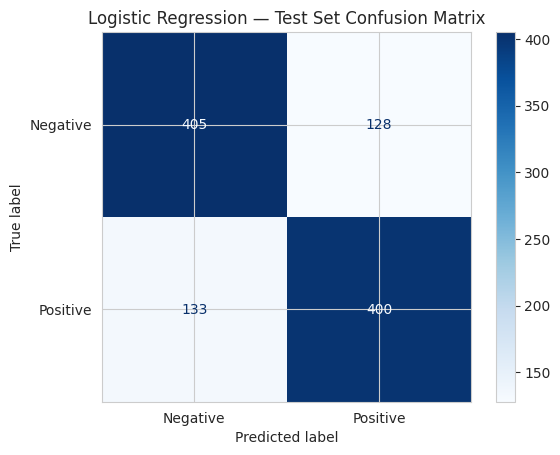

In [ ]:
best_model = grid.best_estimator_
test_preds = best_model.predict(test_df["clean_text"])

print(classification_report(test_df["label"], test_preds, target_names=["Negative", "Positive"]))

cm = confusion_matrix(test_df["label"], test_preds)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(cmap="Blues")
plt.title("Logistic Regression — Test Set Confusion Matrix")
plt.show()


In [ ]:
train_preds = best_model.predict(train_df["clean_text"])
train_acc = accuracy_score(train_df["label"], train_preds)
test_acc = accuracy_score(test_df["label"], test_preds)
gap = train_acc - test_acc

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Train-test gap: {gap:.4f}  ({gap*100:.1f} percentage points)")

if gap > 0.10:
    print("Gap exceeds 10 points -- likely overfitting. Try lowering C (more regularization) or reducing tfidf__max_features.")
elif gap > 0.05:
    print("Moderate gap (5-10 points) -- some overfitting; consider a mild increase in regularization.")
else:
    print("Gap is small -- no strong evidence of overfitting.")


Train accuracy: 0.8012
Test accuracy:  0.7552
Train-test gap: 0.0460  (4.6 percentage points)
Gap is small -- no strong evidence of overfitting.


## 5. Comparison Across Varieties & Conclusion



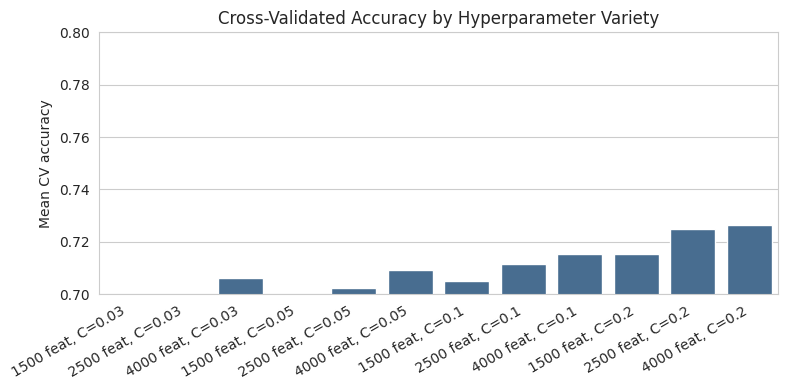

In [ ]:
plt.figure(figsize=(8, 4))
results_plot = results.copy()
results_plot["config"] = results_plot["param_tfidf__max_features"].astype(str) + " feat, C=" + results_plot["param_clf__C"].astype(str)
sns.barplot(data=results_plot, x="config", y="mean_test_score", color="#3C6E9C")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.7, 0.8)
plt.title("Cross-Validated Accuracy by Hyperparameter Variety")
plt.ylabel("Mean CV accuracy")
plt.xlabel("")
plt.tight_layout()
plt.show()


In [ ]:
# ==========================================================
# LIVE INFERENCE TESTING FOR MOVIE REVIEW SENTIMENT
# ==========================================================

# 1. Define a list of mock movie reviews (mix of clear, sarcastic, and complex)
custom_reviews = [
    "An absolute masterpiece! The acting was brilliant and the plot kept me on the edge of my seat.",
    "A total waste of time and money. The script was boring and the ending made absolutely no sense.",
    "I wanted to love this movie, but the terrible pacing completely ruined the experience.",
    "Not bad, but definitely not great either. It had some fun moments though.",
    "Surprisingly good! I went in with incredibly low expectations but left completely blown away.",
    "The special effects were stunning, but everything else about this movie was a complete disaster."
]

print("--- Running Custom Movie Review Inference Tests ---\n")

# 2. Loop through each review and generate a real-time prediction
for i, review in enumerate(custom_reviews, 1):
    # Preprocess the text exactly like your training pipeline
    cleaned_review = clean_text(review)

    # Predict the class (0 = Negative, 1 = Positive)
    pred_label = best_model.predict([cleaned_review])[0]

    # Get the raw probability scores for confidence checking
    pred_probabilities = best_model.predict_proba([cleaned_review])[0]
    confidence = pred_probabilities[pred_label] * 100

    # Convert numerical label to clean string output
    sentiment = "🏆 Positive" if pred_label == 1 else "❌ Negative"

    # Print the raw text and its verdict
    print(f"Review #{i}: \"{review}\"")
    print(f"👉 Predicted Sentiment: {sentiment} ({confidence:.2f}% Confidence)")
    print("-" * 70)


--- Running Custom Movie Review Inference Tests ---

Review #1: "An absolute masterpiece! The acting was brilliant and the plot kept me on the edge of my seat."
👉 Predicted Sentiment: 🏆 Positive (54.30% Confidence)
----------------------------------------------------------------------
Review #2: "A total waste of time and money. The script was boring and the ending made absolutely no sense."
👉 Predicted Sentiment: ❌ Negative (72.46% Confidence)
----------------------------------------------------------------------
Review #3: "I wanted to love this movie, but the terrible pacing completely ruined the experience."
👉 Predicted Sentiment: ❌ Negative (62.77% Confidence)
----------------------------------------------------------------------
Review #4: "Not bad, but definitely not great either. It had some fun moments though."
👉 Predicted Sentiment: ❌ Negative (52.95% Confidence)
----------------------------------------------------------------------
Review #5: "Surprisingly good! I went in wi